<a href="https://colab.research.google.com/github/abeeraz379/Chicago_Crime/blob/main/Chicago_Crime_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  crime dataset for time series analysis
## Original Source: Chicago Data Portal: Crimes 2001 to Present
- Data Description:
All Crimes that were reported in the city of Chicago and their details View Preview
- Includes:
type of crime, exact date/time, lat/long, district/ward, whether there was an arrest, etc.

# load and inspect data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import glob


In [2]:

zip_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/04-DataViz/Week14/Data/Chicago_Crime_2001-2022.zip"
extract_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/04-DataViz/Week14/Data/Chicago_Crime_2001-2022.csv"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")
os.listdir(extract_path)


Extraction complete!


['Data']

In [3]:

csv_files = glob.glob(extract_path + "/Data/*.csv")

print(f"Found {len(csv_files)} CSV files")

df_list = []

for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Combine all into one dataframe
chicago_full = pd.concat(df_list, ignore_index=True)

print(" Combined dataset shape:", chicago_full.shape)
chicago_full.head()

Found 22 CSV files
 Combined dataset shape: (7713109, 12)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


# explore data

In [4]:
chicago_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [5]:
chicago_full.describe()

,ID,Beat,District,Ward,Latitude,Longitude
count,7.713109e+06,7.713109e+06,7.713062e+06,7.098263e+06,7.624424e+06,7.624424e+06
mean,6.971245e+06,1.186294e+03,1.129533e+01,2.275080e+01,4.184217e+01,-8.767152e+01
std,3.471022e+06,7.030648e+02,6.951157e+00,1.384800e+01,8.881122e-02,6.109191e-02
min,6.340000e+02,1.110000e+02,1.000000e+00,1.000000e+00,3.661945e+01,-9.168657e+01
25%,3.759720e+06,6.210000e+02,6.000000e+00,1.000000e+01,4.176873e+01,-8.771369e+01
50%,6.975839e+06,1.034000e+03,1.000000e+01,2.300000e+01,4.185589e+01,-8.766587e+01
75%,1.003820e+07,1.731000e+03,1.700000e+01,3.400000e+01,4.190677e+01,-8.762820e+01
max,1.319278e+07,2.535000e+03,3.100000e+01,5.000000e+01,4.202291e+01,-8.752453e+01


In [6]:
df.isna().sum()

,0
ID,0
Date,0
Primary Type,0
Description,0
Location Description,847
Arrest,0
Domestic,0
Beat,0
District,0
Ward,10


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.columns:
    print(col, df[col].nunique())

ID 238858
Date 112244
Primary Type 31
Description 284
Location Description 134
Arrest 2
Domestic 2
Beat 274
District 23
Ward 50
Latitude 117597
Longitude 117583


# preprocessing

In [9]:
chicago_full['Date'] = pd.to_datetime(chicago_full['Date'])
chicago_full = chicago_full.sort_values('Date')
chicago_full.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
1541,3214584,2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
1445,1927872,2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
1446,4768442,2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
1447,2280620,2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
1448,9755214,2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [10]:
chicago_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7713109 entries, 1541 to 7713008
Data columns (total 12 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Date                  datetime64[ns]
 2   Primary Type          object        
 3   Description           object        
 4   Location Description  object        
 5   Arrest                bool          
 6   Domestic              bool          
 7   Beat                  int64         
 8   District              float64       
 9   Ward                  float64       
 10  Latitude              float64       
 11  Longitude             float64       
dtypes: bool(2), datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 662.0+ MB


In [11]:
df.isna().sum()

,0
ID,0
Date,0
Primary Type,0
Description,0
Location Description,847
Arrest,0
Domestic,0
Beat,0
District,0
Ward,10


# Topic 1) Comparing Police Districts
- Which district had the most crimes in 2022?
- Which had the least?

In [12]:
crime_2022 = chicago_full[chicago_full["Date"].dt.year == 2022]


In [13]:
district_counts = crime_2022["District"].value_counts()

In [14]:

print("Most crimes district:", district_counts.idxmax())
print("Crimes:", district_counts.max())


Most crimes district: 8.0
Crimes: 14805


In [15]:
print("Least crimes district:", district_counts.idxmin())
print("Crimes:", district_counts.min())

Least crimes district: 31.0
Crimes: 15


# Topic 2) Crimes Across the Years:

- Is the total number of crimes increasing or decreasing across the years?
- Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

In [16]:
chicago_full["Year"] = chicago_full["Date"].dt.year

In [17]:

yearly_counts = chicago_full["Year"].value_counts().sort_index()
yearly_counts


,count
Year,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


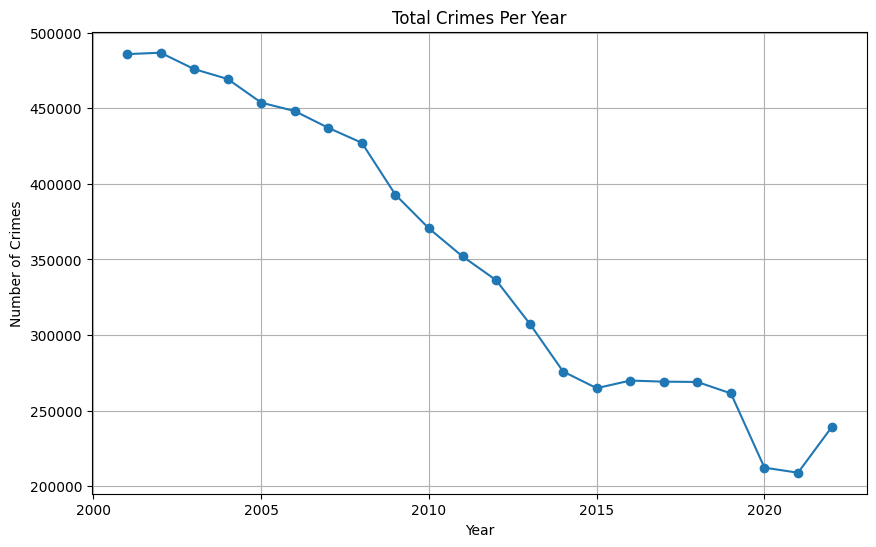

In [18]:

yearly_counts.plot(kind="line", marker="o", figsize=(10,6))
plt.title("Total Crimes Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid()
plt.show()


In [19]:
crime_types_trend = chicago_full.groupby(["Year", "Primary Type"]).size().unstack(fill_value=0)
crime_types_trend.head()


Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,
2001,1011,31384,93461,26014,1,1779,55859,29,13241,14949,...,29662,6026,9,2750,8,18441,2239,204,99277,4277
2002,1032,31523,94153,25623,0,1807,55941,27,13880,13732,...,32600,6408,8,2457,2,18523,2173,200,98332,4281
2003,955,29477,88380,25157,0,1571,55011,41,14807,13459,...,31148,6214,6,2430,2,17332,2078,247,98876,4211
2004,778,28850,87136,24564,0,1538,53164,42,15913,13255,...,29532,7476,9,2495,1,15978,1805,215,95463,4298
2005,691,27067,83964,25503,0,1521,54548,37,16655,13590,...,28028,6124,4,2730,2,16047,1817,192,85684,4106


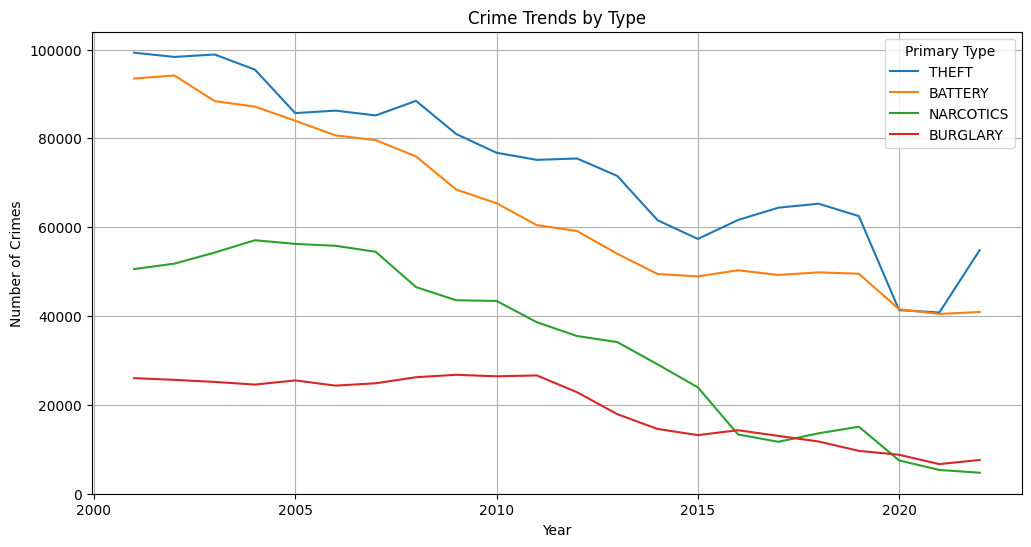

In [20]:
selected_crimes = ["THEFT", "BATTERY", "NARCOTICS", "BURGLARY"]

crime_types_trend[selected_crimes].plot(figsize=(12,6))
plt.title("Crime Trends by Type")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid()
plt.show()

# Topic 3) Comparing AM vs. PM Rush Hour:
- Are crimes more common during AM rush hour or PM rush hour?
You can consider any crime that occurred between 7 AM - 10 AM as AM rush hour
You can consider any crime that occurred between 4 - 7 PM as PM rush hour.
- Answer the question: What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?
- Answer the question: Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

In [21]:
chicago_full["Hour"] = chicago_full["Date"].dt.hour

In [22]:
am_rush = chicago_full[(chicago_full["Hour"] >= 7) & (chicago_full["Hour"] < 10)]
pm_rush = chicago_full[(chicago_full["Hour"] >= 16) & (chicago_full["Hour"] < 19)]

In [23]:
print("AM rush crimes:", len(am_rush))
print("PM rush crimes:", len(pm_rush))

AM rush crimes: 770651
PM rush crimes: 1206353


In [24]:
top5_am = am_rush["Primary Type"].value_counts().head(5)
print("Top 5 AM crimes:\n", top5_am)
top5_pm = pm_rush["Primary Type"].value_counts().head(5)
print("Top 5 PM crimes:\n", top5_pm)

Top 5 AM crimes:
 Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73999
OTHER OFFENSE       62453
Name: count, dtype: int64
Top 5 PM crimes:
 Primary Type
THEFT              293514
BATTERY            213002
CRIMINAL DAMAGE    134101
NARCOTICS          103032
ASSAULT             89600
Name: count, dtype: int64


In [25]:
mv_theft_am = am_rush[am_rush["Primary Type"] == "MOTOR VEHICLE THEFT"]
mv_theft_pm = pm_rush[pm_rush["Primary Type"] == "MOTOR VEHICLE THEFT"]

print("AM Motor Vehicle Theft:", len(mv_theft_am))
print("PM Motor Vehicle Theft:", len(mv_theft_pm))

AM Motor Vehicle Theft: 41578
PM Motor Vehicle Theft: 53716


# Topic 4) Comparing Months:
- Answer the question: What months have the most crime? What months have the least?
- Answer the question: Are there any individual crimes that do not follow this pattern? If so, which crimes?

In [26]:
chicago_full["Month"] = chicago_full["Date"].dt.month

In [27]:
monthly_counts = chicago_full["Month"].value_counts().sort_index()
monthly_counts

,count
Month,
1,601236
2,529391
3,629704
4,627175
5,682932
6,681739
7,717232
8,710444
9,668242


In [28]:
most_month = monthly_counts.idxmax()
least_month = monthly_counts.idxmin()

print("Month with most crimes:", most_month)
print("Crimes:", monthly_counts.max())

print("Month with least crimes:", least_month)
print("Crimes:", monthly_counts.min())

Month with most crimes: 7
Crimes: 717232
Month with least crimes: 2
Crimes: 529391


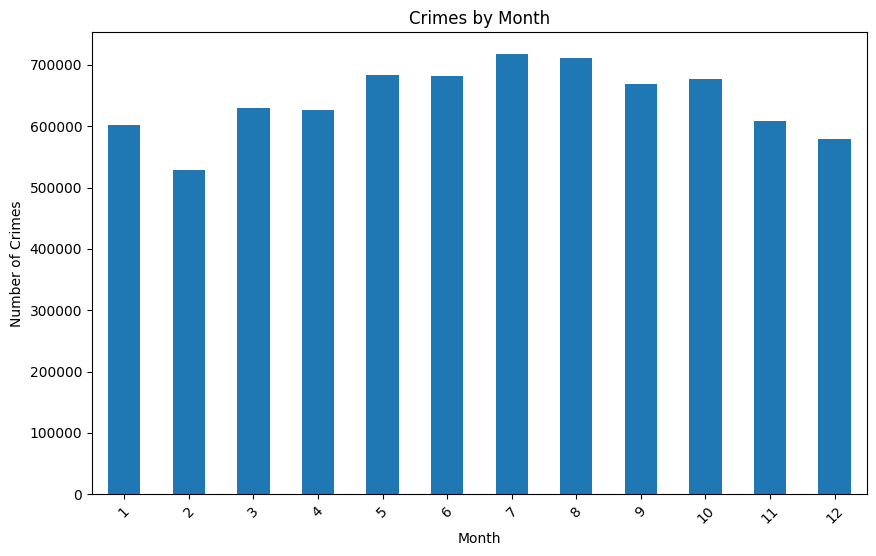

In [29]:

monthly_counts.plot(kind="bar", figsize=(10,6))
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.show()


In [32]:
crime_month_trend = chicago_full.groupby(["Month", "Primary Type"]).size().unstack(fill_value=0)


In [33]:

crime_trend_change = crime_month_trend.diff().mean()

print(crime_trend_change.sort_values(ascending=False).head())
print(crime_trend_change.sort_values().head())

Primary Type
THEFT                  290.000000
BURGLARY               272.363636
ROBBERY                212.454545
MOTOR VEHICLE THEFT    161.000000
CRIMINAL DAMAGE         50.545455
dtype: float64
Primary Type
NARCOTICS           -1092.363636
OTHER OFFENSE        -641.090909
BATTERY              -267.090909
CRIMINAL TRESPASS    -242.454545
PROSTITUTION         -184.636364
dtype: float64


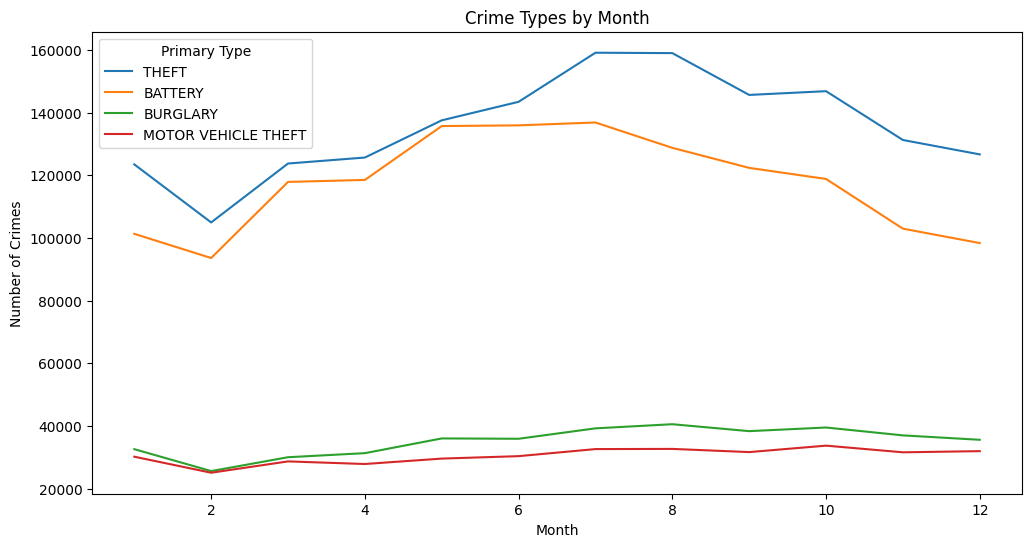

In [34]:
selected = ["THEFT", "BATTERY", "BURGLARY", "MOTOR VEHICLE THEFT"]

crime_month_trend[selected].plot(figsize=(12,6))
plt.title("Crime Types by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()

# Topic 5) Comparing Holidays:
- Answer the question: What are the top 3 holidays with the largest number of crimes?
- Answer the question:  For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

In [35]:
!pip install holidays

In [36]:
import holidays
from holidays import country_holidays

In [37]:
chicago_full["Day"] = chicago_full["Date"].dt.day

In [38]:
us_holidays = country_holidays('US')
us_holidays

holidays.country_holidays('US')

In [46]:
chicago_full["US Holiday"] = [us_holidays.get(day) for day in chicago_full['Date']]

In [47]:

top3_holidays = chicago_full["US Holiday"].head(3)
print(top3_holidays)


1541    New Year's Day
1445    New Year's Day
1446    New Year's Day
Name: US Holiday, dtype: object


In [48]:
holiday_data = chicago_full[chicago_full["US Holiday"].notna()]

top3_holidays = holiday_data["US Holiday"].value_counts().head(3)

print("Top 3 holidays:\n", top3_holidays)


for holiday in top3_holidays.index:
    print(f"\nTop crimes on {holiday}:")

    top_crimes = (
        holiday_data[holiday_data["US Holiday"] == holiday]["Primary Type"]
        .value_counts()
        .head(5)
    )

    print(top_crimes)

Top 3 holidays:
 US Holiday
New Year's Day      32725
Independence Day    22672
Labor Day           22164
Name: count, dtype: int64

Top crimes on New Year's Day:
Primary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64

Top crimes on Independence Day:
Primary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64

Top crimes on Labor Day:
Primary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64


# Topic 6) What cycles (seasonality) can you find in this data?
- Make sure to select the data of interest and resample it to the frequency you want. (For suggestions, See the "Suggested data to check for seasons" list at the bottom of this topic.)
Use statsmodels.tsa.seasonal.seasonal_decompose() to decompose the time series.
- Note: seasonal_decompose cannot read data resampled as minutes or smaller, and if you try seconds, you will crash your computer. Keep your resampling at hours or more.

- Show and describe each cycle you can find.
(Hint: If your seasonal results are too dense to read, try zooming in to look at just one year or one month and try different levels of resampling).
- Answer the question: How long is a cycle?
- Answer the question: What is the magnitude of the cycle? (Compare min and max).

In [52]:
chicago_full = chicago_full.set_index("Date")
daily_crimes = chicago_full.resample("D").size()

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_crimes, model="additive", period=365)


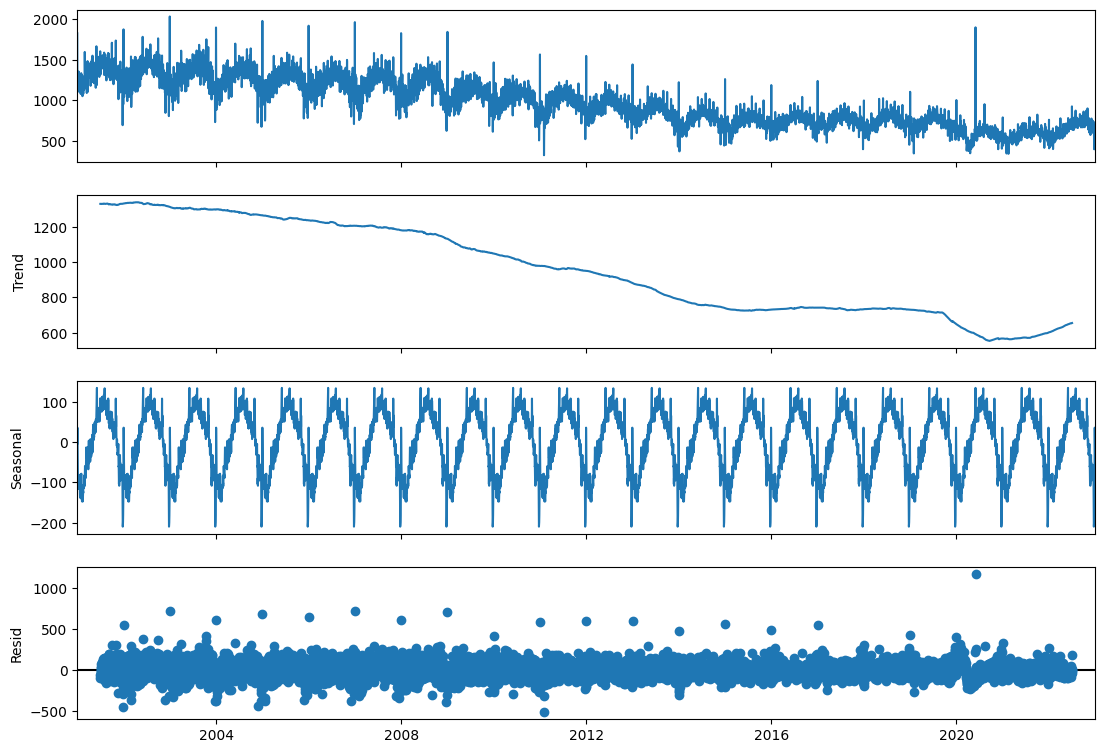

In [54]:

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


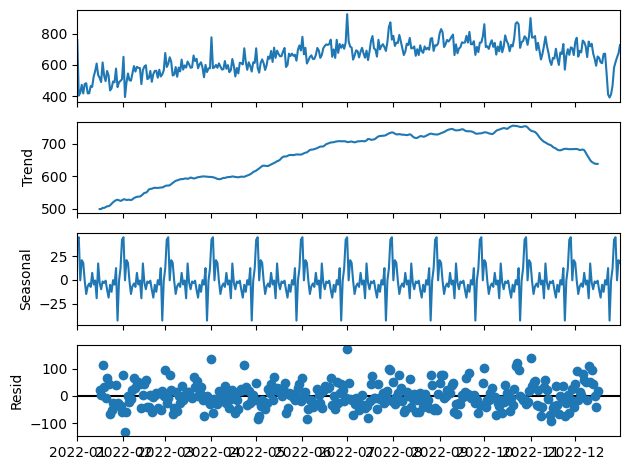

In [59]:

one_year = daily_crimes["2022"]

decomposition_zoom = seasonal_decompose(one_year, model="additive", period=30)

decomposition_zoom.plot()
plt.show()
